In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pickle

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

def save_obj(obj, name ):
    with open('/mnt/scratch/scratch/abh_model/MF/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name ):
    with open('/mnt/scratch/scratch/abh_model/MF/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 'E': -80., #check
       ## Time costants
       'Cm': 1,
       'tau_n': 4,
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }


def m_inf(V):
    return 1.0/(1.0+np.exp((Par['Cmna']-V)/Par['DCmna']))

def n_inf(V):
    return 1.0/(1.0+np.exp((Par['Cnk']-V)/Par['DCnk']))

def h(n):
    return 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n - 0.4)))

def I_K_form(V,n,K_o,K_i):
    return (Par['g_Kl']+Par['g_K']*n)*(V- 26.64*np.log(K_o/K_i)) 

def I_Na_form(V,Na_o,Na_i,n):
    return (Par['g_Nal']+Par['g_Na']*m_inf(V)*h(n))*(V- 26.64*np.log(Na_o/Na_i))

def I_Cl_form(V):
    return Par['g_Cl']*(V+ 26.64*np.log(Par['Cl_o0']/Par['Cl_i0'])) 

def I_pump_form(Na_i,K_o):
    return Par['rho']*(1.0/(1.0+np.exp((Par['Cnap'] - Na_i) / Par['DCnap']))*(1.0/(1.0+np.exp((Par['Ckp'] - K_o)/Par['DCkp'])))) 

def V_dot_form(I_Na,I_K,I_Cl,I_pump):
    return (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump) 

def mean_field_model(z,t,kb,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input): 
    x = z[0]
    V = z[1]
    n = z[2]
    DK_i = z[3]
    Kg = z[4]
    K_bath= kb
    eta_bar_val= eta
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DK_i 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DK_i
    K_i = Par['K_i0'] + DK_i 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    I_K = I_K_form(V,n,K_o,K_i)
    I_Na = I_Na_form(V,Na_o,Na_i,n)
    I_Cl = I_Cl_form(V)
    I_pump = I_pump_form(Na_i,K_o)
    
    #%%%%%% Equations      
    Vdot = (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump)    
    if V <= Vstar:
        dV = Vdot - R_minus*x**2 + eta_bar_val
        dx = Delta + 2*R_minus*(V-c_minus)*x
        
    else:
        dV = Vdot - R_plus*x**2 + eta_bar_val
        dx = Delta + 2*R_plus*(V-c_plus)*x 
    rr=R_minus*x/np.pi + Input
    ninf=n_inf(V)
    
    dV+= J*(rr)*(E-V)
    dx+= -J*(rr)*x
    dn = (ninf - n) / Par['tau_n'] 
    dDK_i = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dx,dV,dn,dDK_i,dKg]
    
    return dz   

def simulate(k, J, eta, Delta, E, z0, Input=0, c_minus=-44.240, c_plus=-20.400, R_minus=0.337, R_plus=-0.381, Vstar=-31):
    #z0 Initial Conditions [x, V, n, DKi, Kg]
    # Simulation time
    min_2_sim=1/3
    min_2_cut=0
    Np= int(min_2_sim*60*1000) #min in milliseconds 
    Np_left= int(min_2_cut*60*1000) #min in milliseconds 
    t = np.linspace(0,Np,Np*1)

    #Parabolas coefficients
    z = odeint(mean_field_model,z0,t, args=(k,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input))

    Meanfield={}
    Meanfield['x']=z[-6000:,0]
    Meanfield['V']=z[-6000:,1]
    Meanfield['n']=z[-6000:,2]
    Meanfield['DK_i']=z[-6000:,3]
    Meanfield['Kg']=z[-6000:,4]
    Meanfield['Par']={}
    Meanfield['Par']['Kbath']=k
    Meanfield['Par']['J']=J
    Meanfield['Par']['eta']=eta
    Meanfield['Par']['Delta']=Delta
    Meanfield['Par']['E']=E
    Meanfield['Par']['z0']=z0
    
    return Meanfield

In [6]:
k=5.5
J=0.08
eta=0
Delta=1
E=0
z0=[0.1,-15.0, 0.45, -5, -16.0]
R_minus=0.02
R_plus=-0.1
c_minus=-44.24
c_plus=-20.4

MF=simulate(k, J, eta, Delta, E, z0,c_minus=c_minus,c_plus=c_plus,R_minus=R_minus,R_plus=R_plus)

In [7]:
x=MF['x']
V=MF['V']
n=MF['n']
DKi=MF['DK_i']
Kg=MF['Kg']

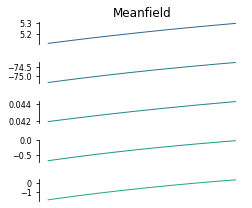

In [8]:
fig = plt.figure(figsize=(3.6,3.))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
path='/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/Figures/Fig6/'
#plt.savefig(path+'Fig6_regime_MF.pdf',dpi=300,transparent=True)
plt.show()

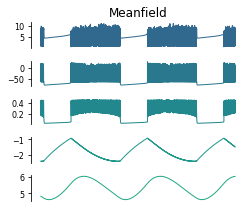

In [216]:
fig = plt.figure(figsize=(3.6,3.))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
path='/Users/giovanni/Documents/GitHub/fufo/data/Interim/Abhirup/Figures/Fig6/'
plt.savefig(path+'Fig6_regime_MF.pdf',dpi=300,transparent=True)
plt.show()

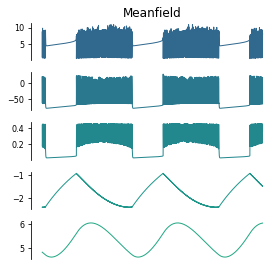

In [213]:
fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

In [198]:
Kg.shape

(6000,)

In [93]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pickle

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

def save_obj(obj, name ):
    with open('/mnt/scratch/scratch/abh_model/MF/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name ):
    with open('/mnt/scratch/scratch/abh_model/MF/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 'E': -80., #check
       ## Time costants
       'Cm': 1,
       'tau_n': 4,
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

def m_inf(V):
    return 1.0/(1.0+np.exp((Par['Cmna']-V)/Par['DCmna']))

def n_inf(V):
    return 1.0/(1.0+np.exp((Par['Cnk']-V)/Par['DCnk']))

def h(n):
    return 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n - 0.4)))

def I_K_form(V,n,K_o,K_i):
    return (Par['g_Kl']+Par['g_K']*n)*(V- 26.64*np.log(K_o/K_i)) 

def I_Na_form(V,Na_o,Na_i,n):
    return (Par['g_Nal']+Par['g_Na']*m_inf(V)*h(n))*(V- 26.64*np.log(Na_o/Na_i))

def I_Cl_form(V):
    return Par['g_Cl']*(V+ 26.64*np.log(Par['Cl_o0']/Par['Cl_i0'])) 

def I_pump_form(Na_i,K_o):
    return Par['rho']*(1.0/(1.0+np.exp((Par['Cnap'] - Na_i) / Par['DCnap']))*(1.0/(1.0+np.exp((Par['Ckp'] - K_o)/Par['DCkp'])))) 

def V_dot_form(I_Na,I_K,I_Cl,I_pump):
    return (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump) 

def mean_field_model(z,t,kb,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input): 
    x = z[0]
    V = z[1]
    n = z[2]
    DK_i = z[3]
    Kg = z[4]
    K_bath= kb
    eta_bar_val= eta
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DK_i 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DK_i
    K_i = Par['K_i0'] + DK_i 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    I_K = I_K_form(V,n,K_o,K_i)
    I_Na = I_Na_form(V,Na_o,Na_i,n)
    I_Cl = I_Cl_form(V)
    I_pump = I_pump_form(Na_i,K_o)
    
    #%%%%%% Equations      
    Vdot = (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump)    
    rr=R_minus*x/np.pi + Input
    ninf=n_inf(V)
    
    if V < Vstar:
        dx = Delta + 2*R_minus*(V-c_minus)*x  -J*(rr)*x
        dV = Vdot - R_minus*x**2 + eta_bar_val  +J*(rr)*(E-V)
    else:
        dx = Delta + 2*R_plus*(V-c_plus)*x -J*(rr)*x
        dV = Vdot - R_plus*x**2 + eta_bar_val +J*(rr)*(E-V)
        
    dn = (ninf - n) / Par['tau_n'] 
    dDK_i = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dx,dV,dn,dDK_i,dKg]
    
    return dz   

def simulate(k, J, eta, Delta, E, z0, Input=0, c_minus=-44.240, c_plus=-20.400, R_minus=0.337, R_plus=-0.381, Vstar=-31):
    #z0 Initial Conditions [x, V, n, DKi, Kg]
    # Simulation time
    min_2_sim=1/3
    min_2_cut=0
    Np= int(min_2_sim*60*1000) #min in milliseconds 
    Np_left= int(min_2_cut*60*1000) #min in milliseconds 
    t = np.linspace(0,Np,Np*1)

    #Parabolas coefficients
    z = odeint(mean_field_model,z0,t, args=(k,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input))

    Meanfield={}
    Meanfield['x']=z[-6000:,0]
    Meanfield['V']=z[-6000:,1]
    Meanfield['n']=z[-6000:,2]
    Meanfield['DK_i']=z[-6000:,3]
    Meanfield['Kg']=z[-6000:,4]
    Meanfield['Par']={}
    Meanfield['Par']['Kbath']=k
    Meanfield['Par']['J']=J
    Meanfield['Par']['eta']=eta
    Meanfield['Par']['Delta']=Delta
    Meanfield['Par']['E']=E
    Meanfield['Par']['z0']=z0
    
    return Meanfield

In [134]:
k=15.5
J=0.002
eta=5
Delta=1
E=0
z0=[0.1,-15.0, 0.45, -5, -16.0]
R_minus=0.15
R_plus=-0.15
c_minus=-65
c_plus=-25

MF=simulate(k, J, eta, Delta, E, z0,c_minus=c_minus,c_plus=c_plus,R_minus=R_minus,R_plus=R_plus) #,c_minus=c_minus,

In [135]:
x=MF['x']
V=MF['V']
n=MF['n']
DKi=MF['DK_i']
Kg=MF['Kg']

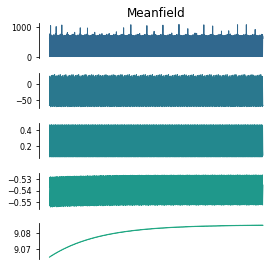

In [136]:
fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

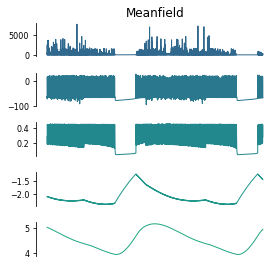

In [123]:
R_minus=0.5
R_plus=-0.5
c_minus=-60
c_plus=-30

fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

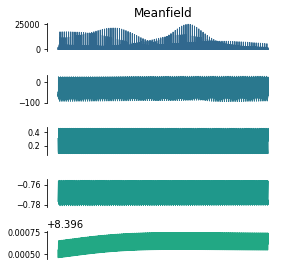

In [116]:
# R_minus=1.5
# R_plus=-0.5
# c_minus=-60
# c_plus=-20

fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

In [36]:
Meanfield={}
Meanfield['x']=z[-6000:,0]
Meanfield['V']=z[-6000:,1]
Meanfield['n']=z[-6000:,2]
Meanfield['DK_i']=z[-6000:,3]
Meanfield['Kg']=z[-6000:,4]
Meanfield['Par']={}
Meanfield['Par']['Kbath']=k
Meanfield['Par']['J']=J
Meanfield['Par']['eta']=eta
Meanfield['Par']['Delta']=Delta
Meanfield['Par']['E']=E
Meanfield['Par']['z0']=z0

In [28]:
save_obj(MF, 'MF_%s'%str(Meanfield['Par']))

[1.6]

In [29]:


Meanfield['Par']={}
Meanfield['Par']['Kbath']=k
Meanfield['Par']['J']=J
Meanfield['Par']['eta']=eta
Meanfield['Par']['Delta']=Delta
Meanfield['Par']['E']=E
Meanfield['Par']['z0']=str(z0)

In [33]:
save_obj(Meanfield, 'MF_%s'%str(Meanfield['Par']))

In [37]:
print('MF_%s'%str(Meanfield['Par']))

MF_{'Kbath': 19, 'J': 4, 'eta': 1.6, 'Delta': 1, 'E': -80, 'z0': [0.1, -15.0, 0.45, -5, -16.0]}


In [24]:
import pickle
def save_obj(obj, name ):
    with open('/Users/giovanni/Documents/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
    
save_obj(Meanfield, 'MEANFIELD_%s'%str(Meanfield['Par']))

In [25]:
def load_obj(name ):
    with open('/Users/giovanni/Documents/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

In [26]:
MF=load_obj('MEANFIELD_%s'%str(Meanfield['Par']))

In [20]:
print('MEANFIELD_%s'%str(Meanfield['Par']))

MEANFIELD_{'Kbath': 19, 'J': 4, 'eta': 1.6, 'Delta': 1.0, 'E': -80.0, 'z0': '[0.1, -15.0, 0.45, -5, -16.0]'}


In [12]:
z.shape

(20000, 5)

In [11]:
print('MEANFIELD_Kb%.1f_J%.1f_eta%.1f_Delta%.1f_E%d_z0%s'%(k,J_vec[0],eta_vec[0],Delta,E,str(z0)))

MEANFIELD_Kb19.0_J4.0_eta1.6_Delta1.0_E-80_z0[0.1, -15.0, 0.45, -5, -16.0]


In [16]:
Meanfield['Par']

{'Kbath': 19,
 'J': 4,
 'eta': 1.6,
 'Delta': 1.0,
 'E': -80.0,
 'z0': '[0.1, -15.0, 0.45, -5, -16.0]'}

In [42]:
def save_obj(obj, name ):
    with open('/mnt/scratch/scratch/abh_model/MF/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)
def load_obj(name ):
    with open('/mnt/scratch/scratch/abh_model/MF/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

In [ ]:
import plotext as pltx
V=z[::100,1][-600:,1]
pltx.scatter(V)
pltx.show()

In [2]:
import plotext as pltx
V=z[-540000:-60000,1]
pltx.scatter(V)
pltx.show()

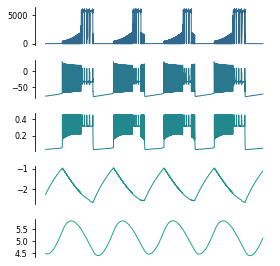

In [40]:
x=z[-540000:-60000,0]
V=z[-540000:-60000,1]
n=z[-540000:-60000,2]
DKi=z[-540000:-60000,3]
Kg=z[-540000:-60000,4]

from matplotlib import cm
viridis = cm.get_cmap('viridis', 16)

fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
plt.show()

In [55]:


#save_obj(Meanfield,'Meanfield')

In [56]:
ini=-540000
fini=-60000
x=z[ini:fini,0]
V=z[ini:fini,1]
n=z[ini:fini,2]
DKi=z[ini:fini,3]
Kg=z[ini:fini,4]

In [57]:
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

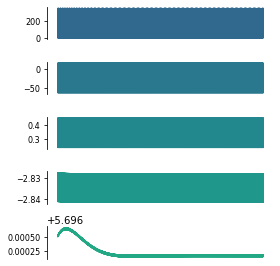

In [59]:
fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()

# Bifurcation diagram

In [14]:
k=5 # K bath value

np.random.seed(42)
x0 = np.random.uniform(0,1,25)
V0= np.random.uniform(-60,10,25)
n0= np.random.uniform(0,0.5,25)
DKi0= np.random.uniform(-5,5,25)
#Kg must satisfy conditions
beta= Par['w_i'] / Par['w_o'] 
Kg0=beta*DKi0-Par['K_o0']+10*np.random.rand(1)

In [15]:
x0

array([0.37454012, 0.95071431, 0.73199394, 0.59865848, 0.15601864,
       0.15599452, 0.05808361, 0.86617615, 0.60111501, 0.70807258,
       0.02058449, 0.96990985, 0.83244264, 0.21233911, 0.18182497,
       0.18340451, 0.30424224, 0.52475643, 0.43194502, 0.29122914,
       0.61185289, 0.13949386, 0.29214465, 0.36636184, 0.45606998])

In [177]:
V0

array([ -5.0376827 , -46.02283525, -24.00358931, -18.53098018,
       -56.74847111, -17.47186037, -48.06331134, -55.44638849,
         6.42198761,   7.59424232,  -3.41218563, -38.67703616,
       -53.16295202, -12.10368814, -29.18932544, -51.45732356,
       -25.33761629, -57.59280352,   3.65242815, -41.88540129,
       -13.6234401 , -38.18022467, -23.59523852, -21.73028045,
       -47.06018811])

In [178]:
n0

array([0.48479231, 0.38756641, 0.46974947, 0.44741368, 0.29894999,
       0.46093712, 0.04424625, 0.09799143, 0.02261364, 0.16266517,
       0.19433864, 0.13567452, 0.41436875, 0.17837666, 0.14046725,
       0.27134804, 0.07046211, 0.40109849, 0.03727532, 0.49344347,
       0.38612238, 0.09935784, 0.00276106, 0.40773071, 0.35342867])

In [179]:
DKi0

array([ 2.29007168,  2.71270347, -4.25955348, -1.41534271, -3.8413094 ,
        3.63103426,  1.23298127, -1.69101975, -4.3644165 , -1.89017678,
       -1.74816678,  2.29606178,  1.37557471,  3.87212743, -0.27785075,
       -3.80405754,  2.13244787,  2.60785049,  0.61277198,  2.7096718 ,
       -0.06204404,  0.22732829, -0.72458982, -4.74580873, -3.92108573])

In [180]:
Kg0

array([  2.3845069 ,   3.65240226, -17.26436859,  -8.73173629,
       -16.00963636,   6.40739463,  -0.78676434,  -9.5587674 ,
       -17.57895763, -10.15623849,  -9.73020848,   2.40247721,
        -0.358984  ,   7.13067413,  -5.31926039, -15.89788076,
         1.91163547,   3.33784332,  -2.64739222,   3.64330726,
        -4.67184025,  -3.80372326,  -6.65947759, -18.72313434,
       -16.24896533])

In [17]:
Input=np.linspace(0,4,21)
Input

array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4,
       2.6, 2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. ])

In [18]:
Input2=np.linspace(4.2,8,20)
Input2

array([4.2, 4.4, 4.6, 4.8, 5. , 5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4, 6.6,
       6.8, 7. , 7.2, 7.4, 7.6, 7.8, 8. ])

In [182]:
#Kg and DKi must satisfy conditions Kg>beta*DKi-Par['K_o0']

In [19]:
Meanfield_Bif_I=load_obj('Meanfield_Bif_I')

In [22]:
#Meanfield_Bif_I={}
for ij in range(13):
    print(ij)
    #Meanfield_Bif_I[ij]={} 
    z0 = [x0[ij],V0[ij], n0[ij], DKi0[ij], Kg0[ij]]
    for ii, i in enumerate(Input2):
        z = odeint(mean_field_model,z0,t, args=(k,eta_vec[0],J_vec[0],Delta,Vstar,c_minus,c_plus,R_minus,R_plus,i))
        Meanfield_Bif_I[ij][i]={} 
        Meanfield_Bif_I[ij][i]['x']=z[:,0]
        Meanfield_Bif_I[ij][i]['V']=z[:,1]
        Meanfield_Bif_I[ij][i]['n']=z[:,2]
        Meanfield_Bif_I[ij][i]['DK_i']=z[:,3]
        Meanfield_Bif_I[ij][i]['Kg']=z[:,4]

0
1
2
3
4
5
6
7
8
9
10
11
12


In [23]:
save_obj(Meanfield_Bif_I,'Meanfield_Bif_I')

OSError: [Errno 28] No space left on device

In [ ]:
save_obj(Meanfield_Bif_I,'Meanfield_Bif_I')

In [261]:
Meanfield_Bif_I.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13])

In [227]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

viridis = plt.get_cmap('viridis')
new_viridis = ListedColormap(viridis(np.arange(12)))

In [230]:
viridis

In [262]:
Input_tot=np.append(np.append(np.append(Input,Input2),Input3),Input4)

In [25]:
Input_tot=np.append(Input,Input2)

In [26]:
Input_tot

array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4,
       2.6, 2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. ,
       5.2, 5.4, 5.6, 5.8, 6. , 6.2, 6.4, 6.6, 6.8, 7. , 7.2, 7.4, 7.6,
       7.8, 8. ])

In [27]:
Varx=np.zeros((12,len(Input_tot)))
Meanx=np.zeros((12,len(Input_tot)))
for ij in range(12):
    for ii, i in enumerate(Input_tot):
        Varx[ij,ii]=np.var(Meanfield_Bif_I[ij][i]['x'][-300000:])
        Meanx[ij,ii]=np.mean(Meanfield_Bif_I[ij][i]['x'][-300000:])

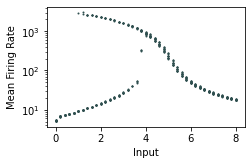

In [29]:
#    Meanx~(#initialcond,len(Input_tot))
plt.figure(figsize=(3.6,2.4))
#plt.title('Bifurcation diagram, $K_{bath}=5$')
plt.semilogy(Input_tot,(1000*R_minus/np.pi)*Meanx.T,'.',markersize=2.,c='darkslategray')
plt.ylabel('Mean Firing Rate')
plt.xlabel('Input')
plt.tight_layout()
plt.savefig('Figures/Bifurcation_I_Meanx.pdf')
plt.show()

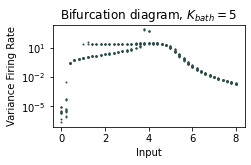

In [268]:
plt.figure(figsize=(3.6,2.4))
plt.title('Bifurcation diagram, $K_{bath}=5$')
plt.semilogy(Input_tot,(1000*R_minus/np.pi)*Varx.T,'.',markersize=2.,c='darkslategray')
plt.ylabel('Variance Firing Rate')
plt.xlabel('Input')
plt.tight_layout()
plt.savefig('Figures/Bifurcation_I_Varx.pdf')
plt.show()

In [189]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pickle

from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

viridis = cm.get_cmap('viridis', 16)
print(viridis)

def save_obj(obj, name ):
    with open('/mnt/scratch/scratch/abh_model/MF/'+ name + '.pkl', 'wb') as f:
        pickle.dump(obj, f, pickle.HIGHEST_PROTOCOL)

def load_obj(name ):
    with open('/mnt/scratch/scratch/abh_model/MF/' + name + '.pkl', 'rb') as f:
        return pickle.load(f)

Par = {'Cnap': 21.0,  # mol.m**-3 
       'DCnap': 2.0,  # mol.m**-3 
       'Ckp': 5.5,  # mol.m**-3 
       'DCkp': 1.0,  # mol.m**-3 
       'Cmna': -24.0,  # mV 
       'DCmna': 12.0,  # mV 
       'Chn': 0.4,  # dimensionless 
       'DChn': -8.0,  # dimensionless 
       'Cnk': -19.0,  # mV 
       'DCnk': 18.0,  # mV #Ok in the paper
       'g_Cl': 7.5,  # nS #Ok in the paper
       'g_Na': 40.0,  # nS 
       'g_K': 22.0,  # nS 
       'g_Nal': 0.02,  # nS 
       'g_Kl': 0.12,  # nS 
       'rho': 250.,  # 250.,#pamp 
       'w_i': 2160.0,  # umeter 
       'w_o': 720.0,  # umeter 
       'K_bath': 12.5,  # mol.m**-3
       'Na_i0': 16.0,  # mol.m**-3 
       'Na_o0': 138.0,  # mol.m**-3 
       'K_i0': 130.0,  # mol.m**-3 
       'K_o0': 4.80,  # mol.m**-3 
       'Cl_o0': 112.0,  # mol.m**-3 
       'Cl_i0': 5.0,  # mol.m**-3 'E': -80., #check
       ## Time costants
       'Cm': 1,
       'tau_n': 4,
       'gamma': 0.04,  
       'epsilon': 0.001,
       'tau_I': 1
      }

def m_inf(V):
    return 1.0/(1.0+np.exp((Par['Cmna']-V)/Par['DCmna']))

def n_inf(V):
    return 1.0/(1.0+np.exp((Par['Cnk']-V)/Par['DCnk']))

def h(n):
    return 1.1 - 1.0 / (1.0 + np.exp(-8.0 * (n - 0.4)))

def I_K_form(V,n,K_o,K_i):
    return (Par['g_Kl']+Par['g_K']*n)*(V- 26.64*np.log(K_o/K_i)) 

def I_Na_form(V,Na_o,Na_i,n):
    return (Par['g_Nal']+Par['g_Na']*m_inf(V)*h(n))*(V- 26.64*np.log(Na_o/Na_i))

def I_Cl_form(V):
    return Par['g_Cl']*(V+ 26.64*np.log(Par['Cl_o0']/Par['Cl_i0'])) 

def I_pump_form(Na_i,K_o):
    return Par['rho']*(1.0/(1.0+np.exp((Par['Cnap'] - Na_i) / Par['DCnap']))*(1.0/(1.0+np.exp((Par['Ckp'] - K_o)/Par['DCkp'])))) 

def V_dot_form(I_Na,I_K,I_Cl,I_pump):
    return (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump) 

def mean_field_model(z,t,kb,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input): 
    x = z[0]
    V = z[1]
    n = z[2]
    DK_i = z[3]
    Kg = z[4]
    s = z[5]
    K_bath= kb
    eta_bar_val= eta
    
    beta= Par['w_i'] / Par['w_o'] 
    DNa_i = -DK_i 
    DNa_o = -beta * DNa_i
    DK_o = -beta * DK_i
    K_i = Par['K_i0'] + DK_i 
    Na_i = Par['Na_i0'] + DNa_i 
    Na_o = Par['Na_o0'] + DNa_o 
    K_o = Par['K_o0'] + DK_o + Kg 
    
    I_K = I_K_form(V,n,K_o,K_i)
    I_Na = I_Na_form(V,Na_o,Na_i,n)
    I_Cl = I_Cl_form(V)
    I_pump = I_pump_form(Na_i,K_o)
    
    #%%%%%% Equations      
    Vdot = (-1.0/Par['Cm'])*(I_Na+I_K+I_Cl+I_pump)    
    rr=R_minus*x/np.pi + Input
    ninf=n_inf(V)
    
    if V < Vstar:
        dx = Delta + 2*R_minus*(V-c_minus)*x  -J*(s)*x
        dV = Vdot - R_minus*x**2 + eta_bar_val  +J*(s)*(E-V)
    else:
        dx = Delta + 2*R_plus*(V-c_plus)*x -J*(s)*x
        dV = Vdot - R_plus*x**2 + eta_bar_val +J*(s)*(E-V)
    ds=(-s+rr)/0.005
        
    dn = (ninf - n) / Par['tau_n'] 
    dDK_i = -(Par['gamma'] / Par['w_i']) * (I_K - 2.0 * I_pump)
    dKg = Par['epsilon'] * (K_bath - K_o)
    
    dz = [dx,dV,dn,dDK_i,dKg,ds]
    
    return dz   

def simulate(k, J, eta, Delta, E, z0, Input=0, c_minus=-44.240, c_plus=-20.400, R_minus=0.337, R_plus=-0.381, Vstar=-31):
    #z0 Initial Conditions [x, V, n, DKi, Kg]
    # Simulation time
    min_2_sim=1/3
    min_2_cut=0
    Np= int(min_2_sim*60*1000) #min in milliseconds 
    Np_left= int(min_2_cut*60*1000) #min in milliseconds 
    t = np.linspace(0,Np,Np*1)

    #Parabolas coefficients
    z = odeint(mean_field_model,z0,t, args=(k,eta,J,Delta,Vstar,c_minus,c_plus,R_minus,R_plus,Input))

    Meanfield={}
    Meanfield['x']=z[-6000:,0]
    Meanfield['V']=z[-6000:,1]
    Meanfield['n']=z[-6000:,2]
    Meanfield['DK_i']=z[-6000:,3]
    Meanfield['Kg']=z[-6000:,4]
    Meanfield['s']=z[-6000:,5]
    Meanfield['Par']={}
    Meanfield['Par']['Kbath']=k
    Meanfield['Par']['J']=J
    Meanfield['Par']['eta']=eta
    Meanfield['Par']['Delta']=Delta
    Meanfield['Par']['E']=E
    Meanfield['Par']['z0']=z0
    
    return Meanfield

In [190]:
k=15.5
J=0.002
eta=5
Delta=1
E=0
z0=[0.1,-15.0, 0.45, -5, -16.0,0.2]

MF=simulate(k, J, eta, Delta, E, z0) #,c_minus=c_minus,

In [191]:
x=MF['x']
V=MF['V']
n=MF['n']
DKi=MF['DK_i']
Kg=MF['Kg']
s=MF['s']

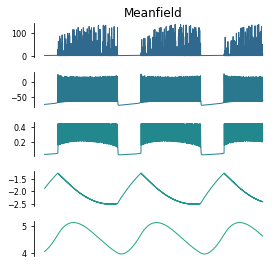

In [192]:
fig = plt.figure(figsize=(4,3.8))
ax1 = fig.add_subplot(511)
ax1.set_title('Meanfield')
ax1.plot((1000*R_minus/np.pi)*x,c=viridis(5),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(512)
ax1.plot(V,c=viridis(6),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(513)
ax1.plot(n,c=viridis(7),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(514)
ax1.plot(DKi,c=viridis(8),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

ax1 = fig.add_subplot(515)
ax1.plot(Kg,c=viridis(9),linewidth=1)
ax1.spines["top"].set_visible(False)
ax1.spines["bottom"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.set_xticks([])
ax1.tick_params(axis='both',labelsize=8)

plt.tight_layout()
#plt.savefig('Figures/J2Regime.pdf')
plt.show()